<a href="https://colab.research.google.com/github/sreechandhana54/basic-python/blob/main/house_prices_prediction(using_linear_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib scikit-learn

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
data = {
    'Area': ['Whitefield', 'Koramangala', 'Jayanagar', 'HSR Layout', 'Electronic City Phase 1',
             'Electronic City Phase 2', 'Marathahalli', 'Sarjapur', 'Bellandur', 'Malleswaram',
             'Banashankari', 'Devanahalli', 'Anekal', 'Hebbal', 'BTM Layout'],
    'Area_sqft': [1200, 1500, 1300, 1100, 1400, 1450, 1250, 1350, 1250, 1100, 1150, 1600, 1000, 1500, 1200],
    'BHK': [2, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 2, 3, 2],
    'Bathrooms': [2, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 2],
    'Occupancy': [2, 4, 3, 2, 4, 4, 3, 3, 2, 3, 3, 4, 2, 4, 2],
    'Floor': ['Ground', '1st', '2nd', '1st', '2nd', 'Ground', '1st', '2nd', 'Ground', '1st', '2nd', '1st', 'Ground', '2nd', '1st'],
    'Price_Lakhs': [70, 120, 100, 80, 110, 115, 75, 95, 90, 85, 80, 105, 60, 125, 78]
}
df = pd.DataFrame(data)

In [33]:
X = df.drop('Price_Lakhs', axis=1)
y = df['Price_Lakhs']
X = pd.get_dummies(X, columns=['Area', 'Floor'])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

R² Score: 0.5022830945945949
Root Mean Squared Error: 10.114765197472453


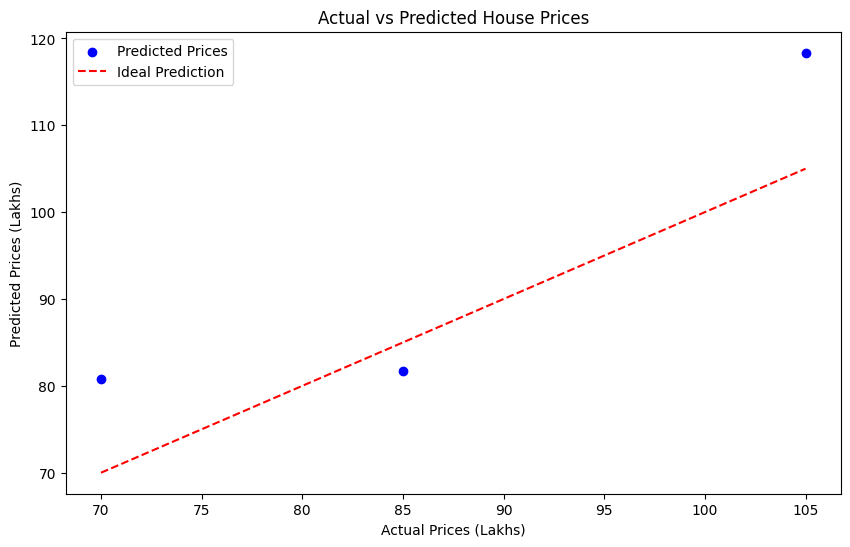

In [45]:
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted Prices')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel("Actual Prices (Lakhs)")
plt.ylabel("Predicted Prices (Lakhs)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()


In [52]:
print("\nEnter house details to predict price:")
valid_areas = df['Area'].tolist()
area = input(f"Select Area {valid_areas}: ").title()
while area not in valid_areas:
    area = input(f"Invalid area! Please select a valid area from {valid_areas}: ").title()
area_sqft = float(input("Enter Area in sqft: "))
bhk = int(input("Enter BHK (1,2,3): "))
bathrooms = int(input("Enter Number of Bathrooms: "))
occupancy = int(input("Enter Number of People living: "))
valid_floors = ['Ground', '1st', '2nd']
while True:
    floor_input = input(f"Enter Floor {valid_floors} (or 1/2/Ground): ").strip().lower()
    if floor_input in ['ground', 'g', '0']:
        floor = 'Ground'
        break
    elif floor_input in ['1', '1st', 'first']:
        floor = '1st'
        break
    elif floor_input in ['2', '2nd', 'second']:
        floor = '2nd'
        break
    else:
        print(f"Invalid floor! Please enter one of {valid_floors} (or 1/2/Ground).")
bedrooms = bhk



Enter house details to predict price:
Select Area ['Whitefield', 'Koramangala', 'Jayanagar', 'HSR Layout', 'Electronic City Phase 1', 'Electronic City Phase 2', 'Marathahalli', 'Sarjapur', 'Bellandur', 'Malleswaram', 'Banashankari', 'Devanahalli', 'Anekal', 'Hebbal', 'BTM Layout']: hyderabab
Invalid area! Please select a valid area from ['Whitefield', 'Koramangala', 'Jayanagar', 'HSR Layout', 'Electronic City Phase 1', 'Electronic City Phase 2', 'Marathahalli', 'Sarjapur', 'Bellandur', 'Malleswaram', 'Banashankari', 'Devanahalli', 'Anekal', 'Hebbal', 'BTM Layout']: sarjapura
Invalid area! Please select a valid area from ['Whitefield', 'Koramangala', 'Jayanagar', 'HSR Layout', 'Electronic City Phase 1', 'Electronic City Phase 2', 'Marathahalli', 'Sarjapur', 'Bellandur', 'Malleswaram', 'Banashankari', 'Devanahalli', 'Anekal', 'Hebbal', 'BTM Layout']: sarjapur
Enter Area in sqft: 11450
Enter BHK (1,2,3): 4
Enter Number of Bathrooms: 3
Enter Number of People living: 4
Enter Floor ['Ground

In [54]:
new_house = pd.DataFrame([{
    'Area_sqft': area_sqft,
    'BHK': bhk,
    'Bathrooms': bathrooms,
    'Occupancy': occupancy,
    'Bedrooms': bedrooms,
    'Area': area,
    'Floor': floor
}])
new_house = pd.get_dummies(new_house)
for col in X.columns:
    if col not in new_house.columns:
        new_house[col] = 0
new_house = new_house[X.columns]
predicted_price = model.predict(new_house)
print(f"\nPredicted House Price: {predicted_price[0]:.2f} Lakhs")



Predicted House Price: 117.80 Lakhs


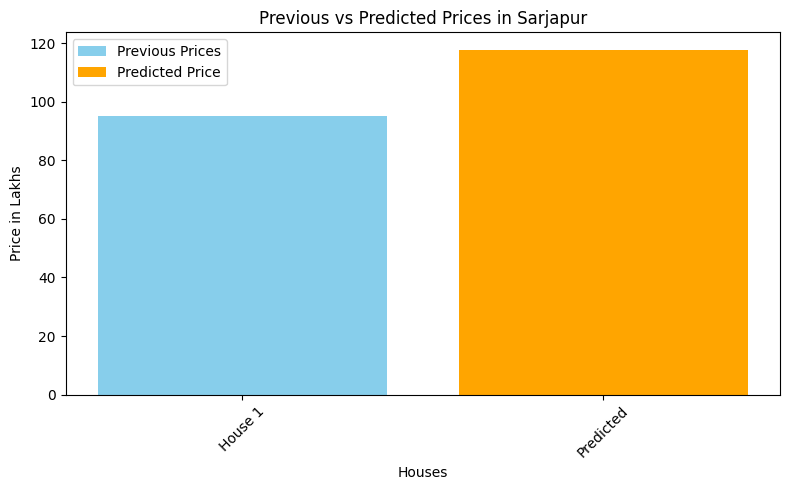

In [55]:
area_prices = df[df['Area'] == area]['Price_Lakhs'].values
num_houses = len(area_prices)
plt.figure(figsize=(8,5))
plt.bar(range(num_houses), area_prices, color='skyblue', label='Previous Prices')
plt.bar(num_houses, predicted_price[0], color='orange', label='Predicted Price')
x_labels = [f"House {i+1}" for i in range(num_houses)] + ['Predicted']
plt.xticks(range(num_houses+1), x_labels, rotation=45)
plt.ylabel("Price in Lakhs")
plt.xlabel("Houses")
plt.title(f"Previous vs Predicted Prices in {area}")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
print(f"Area: {area}")
print(f"Sqft: {area_sqft}, BHK: {bhk}, Bathrooms: {bathrooms}, Occupancy: {occupancy}, Floor: {floor}")

Area: Sarjapur
Sqft: 11450.0, BHK: 4, Bathrooms: 3, Occupancy: 4, Floor: 1st
